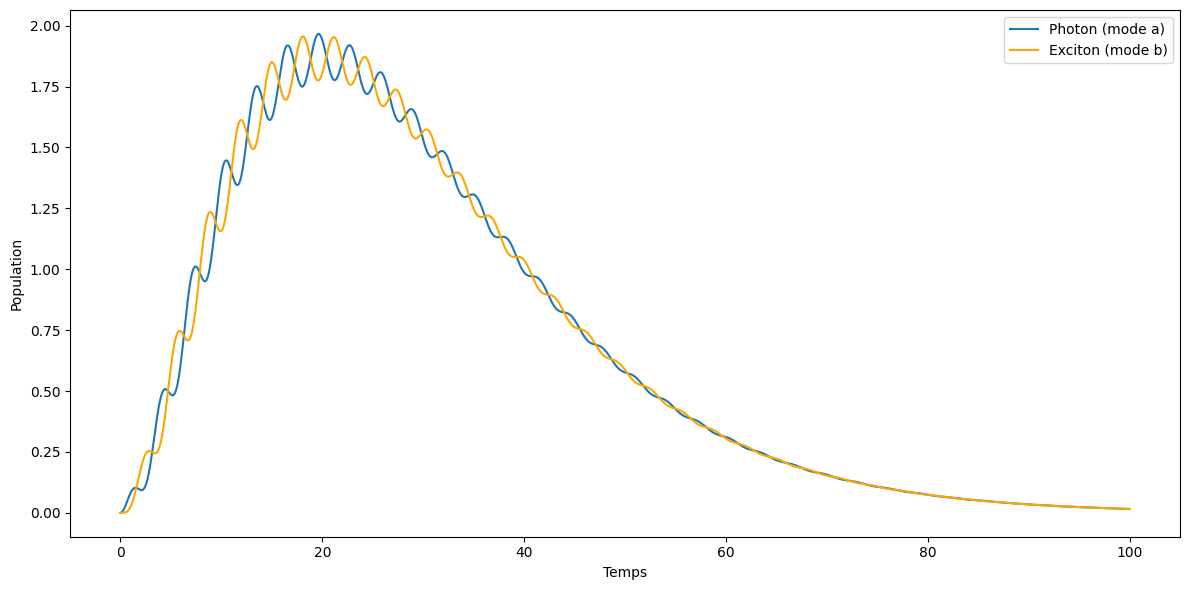

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres du système
omega_c = 1.0   # Fréquence du photon (cavité)
omega_x = 1.0   # Fréquence de l'exciton
g = 1         # Couplage exciton-photon
gamma = 0.1     # Taux de perte des photons
gamma_x = 0.1   # Taux de perte des excitons
r = 1         # Paramètre de squeezing
N = np.sinh(r)**2  # Moyenne des photons dans un état squeezed

# Définir le champ incident (squeezed vacuum)
def squeezed_field(t):
    # On suppose un état squeezed simple (spectre large)
    return np.sqrt(N) * np.exp(-gamma / 2 * t)

# Équations de mouvement pour a(t) et b(t)
def equations(t, z):
    Re_a, Im_a, Re_b, Im_b  = z
    a, b = Re_a + 1j * Im_a, Re_b + 1j * Im_b
    da_dt = -1j * omega_c * a - 1j * g * b - gamma / 2 * a + np.sqrt(gamma) * squeezed_field(t)
    db_dt = -1j * omega_x * b - 1j * g * a - gamma_x/2 * b
    return [np.real(da_dt), np.imag(da_dt), np.real(db_dt), np.imag(db_dt)]

# Conditions initiales
a_0 = 0.0  # Photon initial (vide)
b_0 = 0.0  # Exciton initial (vide)
z0 = [np.real(a_0), np.imag(a_0), np.real(b_0), np.imag(b_0)]

# Intervalle de temps pour la simulation
t_start = 0.0
t_end = 100
num_points = 5000
t_values = np.linspace(t_start, t_end, num_points)

# Intégration numérique avec Runge-Kutta (ordre 4)
from scipy.integrate import solve_ivp
sol = solve_ivp(lambda t, z: equations(t, z), [t_start, t_end], z0, t_eval=t_values)

# Extraire les résultats
a_real = sol.y[0, :] + 1j * sol.y[1, :]
b_real = sol.y[2, :] + 1j * sol.y[3, :]

# Calculer les populations de photons et d'excitons
pop_a = np.abs(a_real)**2
pop_b = np.abs(b_real)**2

# Tracer les résultats
plt.figure(figsize=(12, 6))

# Population des photons
#plt.subplot(1, 2, 1)
#plt.plot(t_values, pop_a, label='Photon (mode a)')
#plt.xlabel('Temps')
#plt.ylabel('Population')
#plt.title('Évolution de la population des photons')

# Population des excitons
#plt.subplot(1, 2, 2)
#plt.plot(t_values, pop_b, label='Exciton (mode b)', color='orange')
#plt.xlabel('Temps')
#plt.ylabel('Population')
#plt.title('Évolution de la population des excitons')


plt.plot(t_values, pop_a, label='Photon (mode a)')
plt.xlabel('Temps')
plt.ylabel('Population')
plt.legend()

plt.plot(t_values, pop_b, label='Exciton (mode b)', color='orange')
plt.xlabel('Temps')
plt.ylabel('Population')
plt.legend()

plt.tight_layout()
plt.show()


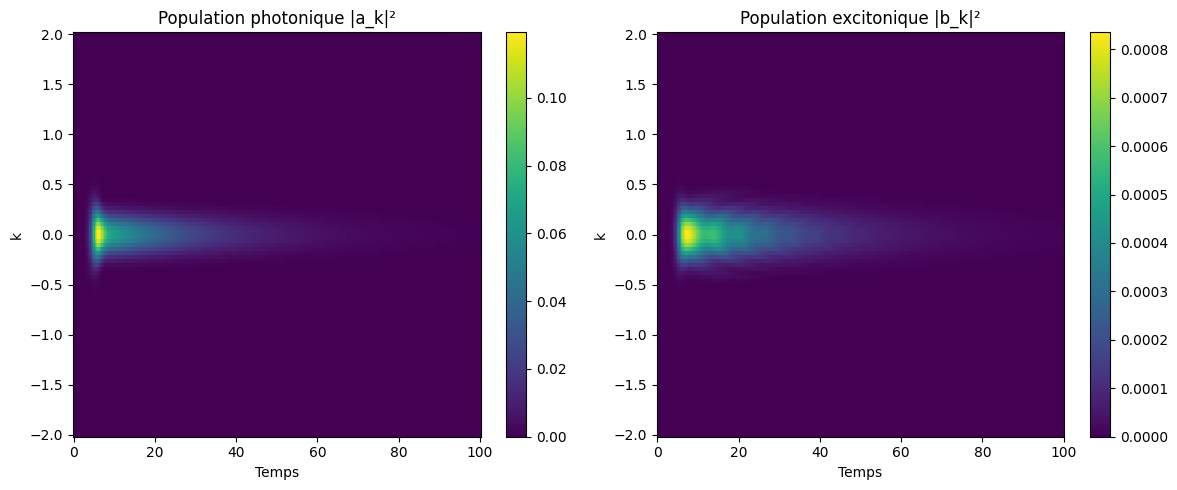

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Paramètres physiques
hbar = 1.0  # unités réduites
omega_c0 = 1.0  # fréquence de cavité à k=0
omega_x0 = 2.0  # fréquence exciton à k=0
m_ph = 0.1  # masse effective du photon
m_x = 10.0   # masse effective de l'exciton
g0 = 0.1    # couplage exciton-photon
gamma = 0.05  # pertes photons
gamma_x = 0.1   # Taux de perte des excitons

# Espace des k
k_vals = np.linspace(-2.0, 2.0, 100)
dk = k_vals[1] - k_vals[0]

# Dispersions en k
omega_c_k = omega_c0 + hbar * k_vals**2 / (2 * m_ph)
omega_x_k = omega_x0 + hbar * k_vals**2 / (2 * m_x)
g_k = g0 * np.ones_like(k_vals)

# Champ incident (état squeezé simulé comme impulsion spectrale gaussienne)
def squeezed_input(t, k):
    N = 1.0  # nombre moyen de photons
    envelope = np.exp(-k**2 / 0.5**2)
    pulse = np.exp(-((t - 5.0) / 2.0)**2)
    return np.sqrt(N) * envelope * pulse

# Équations différentielles couplées pour a_k et b_k
def equations(t, z):
    a_re, a_im, b_re, b_im = z.reshape(4, -1)
    a = a_re + 1j * a_im
    b = b_re + 1j * b_im

    da_dt = -1j * omega_c_k * a - 1j * g_k * b - (gamma / 2) * a + np.sqrt(gamma) * squeezed_input(t, k_vals)
    db_dt = -1j * omega_x_k * b - 1j * g_k * a - gamma_x/2 * b

    return np.concatenate([np.real(da_dt), np.imag(da_dt), np.real(db_dt), np.imag(db_dt)])

# Conditions initiales (vide)
z0 = np.zeros(4 * len(k_vals))

# Intégration temporelle
t_span = (0.0, 100.0)
t_eval = np.linspace(*t_span, 300)
sol = solve_ivp(equations, t_span, z0, t_eval=t_eval)

# Extraction des solutions complexes
a_sol = sol.y[0:len(k_vals), :] + 1j * sol.y[len(k_vals):2*len(k_vals), :]
b_sol = sol.y[2*len(k_vals):3*len(k_vals), :] + 1j * sol.y[3*len(k_vals):, :]

# Calcul des populations
pop_a_k = np.abs(a_sol)**2
pop_b_k = np.abs(b_sol)**2

# Tracer la dynamique
plt.figure(figsize=(12, 5))

# Population photonique
plt.subplot(1, 2, 1)
plt.pcolormesh(t_eval, k_vals, pop_a_k, shading='auto')
plt.xlabel("Temps")
plt.ylabel("k")
plt.title("Population photonique |a_k|²")
plt.colorbar()

# Population excitonique
plt.subplot(1, 2, 2)
plt.pcolormesh(t_eval, k_vals, pop_b_k, shading='auto')
plt.xlabel("Temps")
plt.ylabel("k")
plt.title("Population excitonique |b_k|²")
plt.colorbar()

plt.tight_layout()
plt.show()


### Second Harmonic Generation

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14
})

In [16]:
#Input field
E1 = np.sqrt(0.6)

#Non linear efficiency 
Enl = 0.02


#Reflexion and transmission coeff
r1 = np.sqrt(1 - 0.12)
t1 = np.sqrt(1 - r1**2)
r2 = 1
t2 = np.sqrt(1 - r2**2)
r3 = 1
t3 = np.sqrt(1 - r3**2)
r4 = 1
t4 = np.sqrt(1 - r4**2)

#Linear losses
Lc = 0.02

#Losses due to non linear conversion
gamma = Enl

#Cavity field
#Ec = E1 * t1 / (1-r1*r2*r3*r4*np.sqrt(1 - gamma*Ec**2))

#New variables
lambd = t1**2 + Lc
rho = 4*t1**2*E1**2*Enl

#Ouput field
u = 1 + 13.5*rho/lambd**3*(1 + np.sqrt(1 + 4/27*lambd**3/rho))
P2 = lambd**2 / (9*Enl) * (u**(1/6) - u**(-1/6))**4

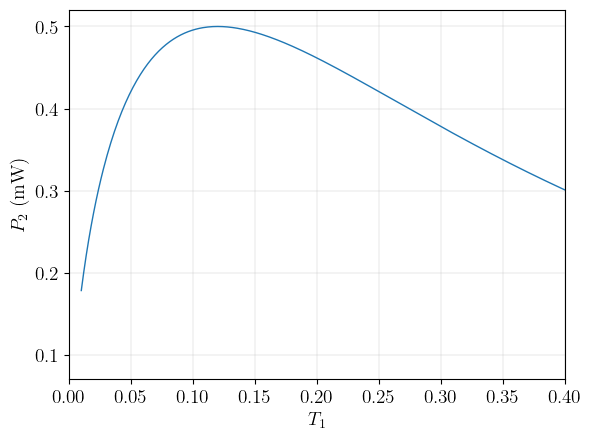

In [17]:
def output_field(T1) : 
    lambd = T1 + Lc
    rho = 4*T1*E1**2*Enl
    u = 1+13.5*rho/lambd**3*(1 + np.sqrt(1 + 4/27*lambd**3/rho))
    v = 1+13.5*rho/lambd**3*(1 - np.sqrt(1 + 4/27*lambd**3/rho))
    P2 = lambd**2 / (9*Enl) * (u**(1/6) - u**(-1/6))**4
    P2 = lambd**2 / (9*Enl) * (u**(1/3) + v**(1/3) - 2)**2
    return P2

transmission = np.linspace(0.01,1,1000)
out_field = [output_field(t) for t in transmission]

fig, ax = plt.subplots()

ax.plot(transmission, out_field, linewidth = 1)
ax.set_xlabel('$T_1$')
ax.set_ylabel('$P_2$ (mW)')
ax.set_xlim(0, 0.4)
ax.grid(linewidth = 0.2)
plt.show()

In [15]:
print(transmission[np.argmax(out_field)])

0.11009009009009009


In [114]:
import numpy as np
import matplotlib.pyplot as plt

# --- Paramètres physiques ---
wavelength = 852e-9  # Longueur d'onde (ex : 1064 nm)
R = 0.15               # Rayon de courbure des miroirs sphériques (en m)
d = 0.17               # Distance entre les deux miroirs courbes (section focalisante)

# --- Fonction de calcul du waist ---
def compute_waist(wavelength, R, d):
    # Paramètres g
    g1 = 1 - d / R
    g2 = g1  # cavité symétrique

    # Vérification de stabilité
    stability = g1 * g2
    if stability <= 0 or stability >= 1:
        raise ValueError(f"Cavité instable : g1*g2 = {stability:.3f}")

    # Calcul du waist (valable dans cavité symétrique et stigmate)
    z_R = d / 2 * np.sqrt(g1 * g2 / (1 - g1 * g2))  # Rayon de courbure de phase
    w0 = np.sqrt(wavelength * z_R / np.pi)
    return w0, stability

# --- Exécution ---
w0, stab = compute_waist(wavelength, R, d)
print(f"Waist (w0) = {w0*1e6:.2f} µm")
print(f"g1 * g2 = {stab:.3f} → cavité stable ✅" if 0 < stab < 1 else "⚠️ Cavité instable")


Waist (w0) = 55.69 µm
g1 * g2 = 0.018 → cavité stable ✅


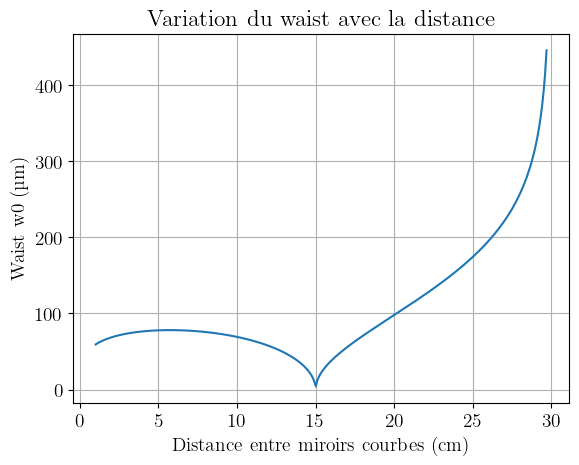

In [72]:
ds = np.linspace(0.01, 0.99 * 2*R, 300)
w0s = []
for d_i in ds:
    try:
        w0, _ = compute_waist(wavelength, R, d_i)
        w0s.append(w0 * 1e6)
    except:
        w0s.append(np.nan)

plt.plot(ds*100, w0s)
plt.xlabel("Distance entre miroirs courbes (cm)")
plt.ylabel("Waist w0 (µm)")
plt.title("Variation du waist avec la distance")
plt.grid()
plt.show()

-2.843180246913583
Waist (w0) ≈ nan µm
67.75972345679014
66.25234264652394
64.76096231405738
63.285582459390625
61.82620308252356
60.38282418345631
58.955445762188724
57.54406781872095
56.14869035305287
54.76931336518453
53.405936855115925
52.0585608228471
50.727185268377966
49.41181019170863
48.112435592839006
46.829061471769094
45.56168782849896
44.31031466302855
43.07494197535789
41.85556976548696
40.6521980334158
39.46482677914436
38.29345600267266
37.1380857040007
35.998715883128476
34.87534654005602
33.76797767478328
32.67660928731029
31.601241377637038
30.541873945763527
29.49850699168976
28.471140515415723
27.459774516941433
26.46440899626689
25.485043953392076
24.521679388317022
23.5743153010417
22.642951691566108
21.72758855989026
20.82822590601417
19.944863729937804
19.077502031661183
18.226140811184294
17.39078006850716
16.571419803629766
15.768060016552113
14.98070070727419
14.209341875796015
13.453983522117582
12.714625646238883
11.991268248159935
11.283911327880718
10.59

/var/folders/z4/n7yq_g310r99kb95d_7_r8p00000gn/T/ipykernel_31771/276470002.py:39: RuntimeWarning: invalid value encountered in sqrt
  w0 = np.sqrt(wavelength / np.pi / np.imag(q_inv))


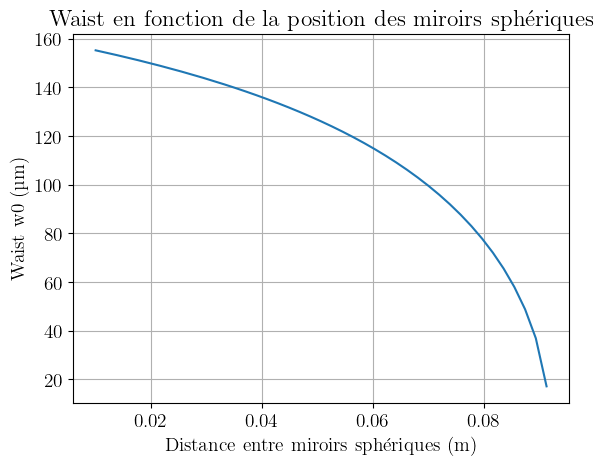

In [124]:
import numpy as np
import matplotlib.pyplot as plt

# --- Paramètres physiques ---
wavelength = 852e-9  # Longueur d'onde (en m)
R = 0.15               # Rayon de courbure des miroirs sphériques (m)
d = 0.17               # Distance entre les deux miroirs sphériques (m)
L_total = 0.79         # Longueur totale du trajet optique dans la cavité (m)
L3 = 0.2
L1 = (L_total - L3 - d)/2
L2 = L1

# --- Matrices ABCD ---
def free_space(L):
    return np.array([[1, L], [0, 1]])

def curved_mirror(R):
    return np.array([[1, 0], [-2/R, 1]])

def round_trip_matrix_bowtie(R, d, L1, L2, L3):
    # Trajet M1 (plan) → M2 (sphérique) → M3 (sphérique) → M4 (plan) → retour M1
    M = (
        #free_space(L1) @         # M1 → M2
        curved_mirror(R) @       # M2
        free_space(d) @          # M2 → M3
        curved_mirror(R) @       # M3
        free_space(L2) @         # M3 → M4
        free_space(L3)           # M4 → M1
    )
    return M


# --- Calcul du waist ---
def compute_waist_from_ABCD(M, wavelength):
    A, B, C, D = M.flatten()
    delta = (A-D)**2 + 4*B*C
    q_inv = (D - A) / (2 * B) + 1j * np.sqrt(np.abs(delta))/(2*B)
    w0 = np.sqrt(wavelength / np.pi / np.imag(q_inv))
    return w0

# --- Exécution ---
M = round_trip_matrix_bowtie(R, d, L1, L2, L3)
w0 = compute_waist_from_ABCD(M, wavelength)
print(f"Waist (w0) ≈ {w0*1e6:.2f} µm")

# --- Optionnel : balayage en distance entre miroirs sphériques ---
ds = np.linspace(0.01, 0.99*L_total, 400)
w0s = []

for d_i in ds:
    try:
        M = round_trip_matrix_bowtie(R, d_i, L1, L2, L3)
        w0 = compute_waist_from_ABCD(M, wavelength)
        w0s.append(w0 * 1e6)
    except Exception:
        w0s.append(np.nan)

plt.plot(ds, w0s)
plt.xlabel("Distance entre miroirs sphériques (m)")
plt.ylabel("Waist w0 (µm)")
plt.title("Waist en fonction de la position des miroirs sphériques")
plt.grid()
plt.show()


In [119]:
L = 0.79
l= 852e-9
print(L/l)

(L - (927230*852e-9))*1e9

927230.0469483569


40.00000008996807

In [120]:
np.cos(6*np.pi/180)

0.9945218953682733